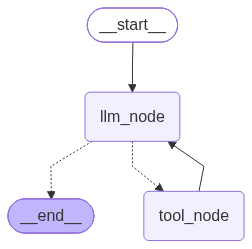

{'messages': [HumanMessage(content='今天北京天气怎么样？国内有什么新闻', additional_kwargs={}, response_metadata={}, id='d4020f03-0f3b-41eb-b763-e3831a554b82'), AIMessage(content='我来帮您查询北京天气和国内新闻。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 359, 'total_tokens': 448, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 359}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '94c2da45-c7e4-468d-9f73-c1ed5d8e6238', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fcabd-6109-7962-a6d6-de492a15de0a-0', tool_calls=[{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_00_WHXw023kqrsopcO1X1YS1544', 'type': 'tool_call'}, {'name': 'get_news', 'args': {'home_or_abroad': True}, 'id': 'call_01_YCz6C9mR905i5ocMWjS68551', 'type'

In [2]:
from typing import Literal

from dotenv import load_dotenv
from langchain.tools import tool
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.constants import END, START
from langgraph.graph import MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

load_dotenv(override=True)


# 1、添加工具调用
@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    查询指定城市的天气

    Args:
         city:城市名称
    """
    return f"{city} 天气晴朗,微风"


@tool(parse_docstring=True)
def get_news(home_or_abroad: bool) -> str:
    """
    查询国内外的新闻

    Args:
        home_or_abroad: 查询国内或者国外的新闻 True:国内新闻 False:国外新闻
    """
    if home_or_abroad:
        return "Kimi 新模型发布"
    return "Anthropic 暂停新模型访问"


model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body=
    {
        "thinking": {
            "type": "disabled"
        }
    }
)

# 2、将工具绑定到模型上
tools_by_name = {
    "get_weather": get_weather,
    "get_news": get_news
}
tools = [get_weather, get_news]
model_with_tools = model.bind_tools(tools=tools)


# 3、声明状态-》传入的时候，直接写HumanMessage
class OverAllState(MessagesState):
    output: str


# 4、定义节点
def llm_node(state: OverAllState) -> OverAllState:
    msg = state["messages"]
    # 调用大模型
    res = model_with_tools.invoke(msg)
    return {
        "messages": [res],
        "output": res.content
    }


def router(state: OverAllState) -> Literal["tool_node", END]:
    if state["messages"][-1].tool_calls:
        return "tool_node"
    return END


# 5 、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", ToolNode(tools=tools))

builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", router, path_map=["tool_node", END])
builder.add_edge("tool_node", "llm_node")

graph = builder.compile()

from IPython.display import display
display(graph)

res = graph.invoke({"messages":[HumanMessage("今天北京天气怎么样？国内有什么新闻")]})
print(res)
for msg in res["messages"]:
    msg.pretty_print()